In [5]:
import pandas as pd
# Load the csv
df=pd.read_csv(r'c:\Users\Maittrish\Downloads\hipparcos-voidmain.csv\hipparcos-voidmain.csv')
#Isolate target features
df=df[["Vmag",'Plx','B-V']]
#Drop missing values
df=df.dropna()
# Parallax (Plx) is an angle. If it is 0 or negative, it means the satellite 
# couldn't get a reliable reading. More importantly, since our distance 
# equation is d = 1/p, a zero or negative parallax will break our math or 
# give us negative distances (which are physically impossible).
df=df[df['Plx']>0]
#Check
print(f"Original data")
print(f"Cleaned data: {df.shape}")

Original data
Cleaned data: (112823, 3)


In [6]:
import numpy as np
#Parallax
p_arsec=df['Plx']/1000.0
#Distance:d=1/p
df['Distance_pc']=1.0/p_arsec
#Absolute magnitude:M=m-5*log10(d)+5
df['AbsMag']=df['Vmag']-5*np.log10(df['Distance_pc'])+5
#Preview
print(df[['Vmag','Plx','Distance_pc','AbsMag']].head())

   Vmag    Plx  Distance_pc    AbsMag
0  9.10   3.54   282.485876  1.845016
1  9.27  21.90    45.662100  5.972221
2  6.61   2.81   355.871886 -1.146468
3  8.06   7.75   129.032258  2.506509
4  8.55   2.87   348.432056  0.839409


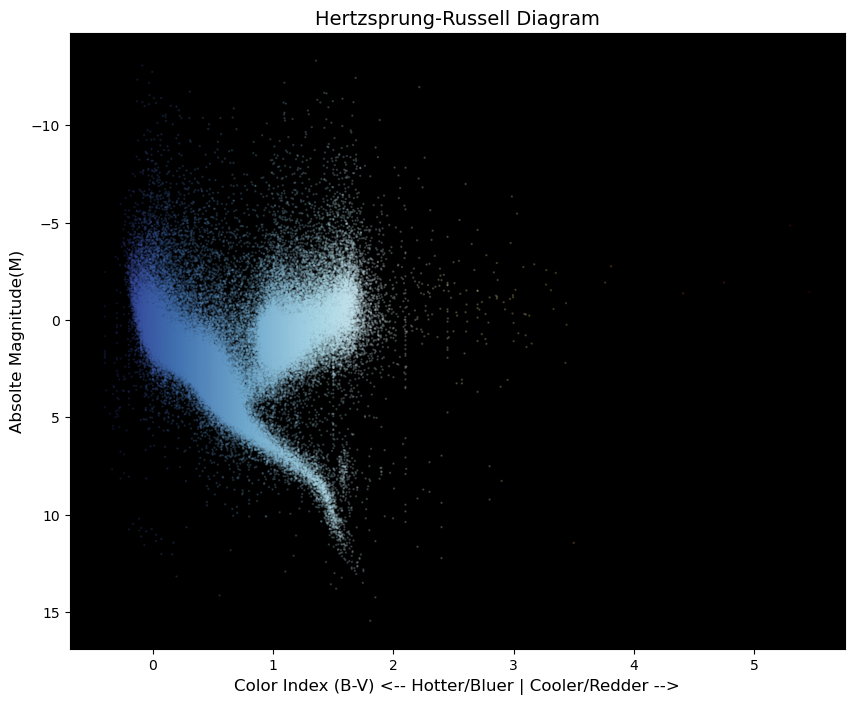

In [11]:
import matplotlib.pyplot as plt
#set up figure
plt.figure(figsize=(10,8))
#Create scatter plot
plt.scatter(df['B-V'],df['AbsMag'],c=df['B-V'],cmap='RdYlBu_r',s=0.5,alpha=0.2)
#Astronomical Gotcha
plt.gca().invert_yaxis()
#Labels
plt.xlabel('Color Index (B-V) <-- Hotter/Bluer | Cooler/Redder -->',fontsize=12)
plt.ylabel('Absolte Magnitude(M)',fontsize=12)
plt.title('Hertzsprung-Russell Diagram',fontsize=14)
#BG colour
plt.gca().set_facecolor('black')
#Render
plt.show()